<a href="https://colab.research.google.com/github/EsserMishelle/Applied-Data-Science-ML/blob/main/Housing_Prices_King_County_MishelleEsser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Predicting Housing Prices in King County

## Dataset
We will use the **King County House Sales dataset**:  
[House Sales Prediction (Kaggle)](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction)

- Contains information on **21,613 house sales** in King County, Washington (includes Seattle).
- Features include:
  - Square footage of living space and lot
  - Number of bedrooms and bathrooms
  - Floors, waterfront view, condition, grade
  - Year built and year renovated
  - Geographic location (latitude, longitude, zip code)
- Target variable: **Sale Price**

---

## Project Goal
- Build regression models to **predict housing prices** based on property features.
- Compare **Linear Regression, Ridge Regression, and Lasso Regression**.
- Evaluate models using metrics:
  - **R²** (variance explained)
  - **MAE** (mean absolute error)
  - **RMSE** (root mean squared error)

---

## Why This Matters
- Housing prices are influenced by many factors: size, location, condition, and more.
- Regression helps us **quantify relationships** and make predictions.
- This project connects data science techniques to a **real-world problem** in economics and urban planning.

---

## Deliverables
1. **Data Exploration**  
   - Summary statistics, distributions, correlations.
2. **Model Building**  
   - Fit Linear, Ridge, and Lasso regression models.
3. **Model Evaluation**  
   - Report R², MAE, RMSE for each model.
   - Interpret coefficients (which features matter most).
4. **Reflection**  
   - Discuss overfitting, regularization, and practical insights.

---

## Key Takeaway
By the end of this project, I will:
- Understand how regression applies to the Kings County housing data.
- Form **model building and evaluation**.
- Explain trade-offs between different regression approaches.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Import the dataset and look at the first 25 rows of the dataset.
housing = pd.read_csv('kc_house_data.csv')

# Make a copy of the original dataframe and store it aside
housing_raw = housing.copy()

housing.head(25)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [12]:
# Before we do anything, we need to inspect the datatype, look at statistic description, the unique values and the null values.
display(housing.shape)
display(housing.info())

(21613, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

None


## Discovery:
 1. The 'date' feature is an object type, and may need to be converted to date type (depening on futher analysis)
 2. Bathrooms are float type
 3. Both 'waterfront' and 'view' are integer type.

In [13]:
view = housing['view'].unique()
print(f'Unique values in view are: {view}')

waterview= housing['waterfront'].unique()
print(f'Unique values in waterview are: {waterview}')

Unique values in view are: [0 3 4 2 1]
Unique values in waterview are: [0 1]


# Waterfront values are either 1 or 0 and view values is 0 to 4

In [14]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [15]:
housing.isnull().sum()
# No null values anywhere in this dataset.

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [16]:
# We will look at the correlation between columns with numberic features
# and the price feature

house_corr= housing.corr(numeric_only=True).round(3)
house_corr

house_price_corr= housing.corr(numeric_only=True)['price'].sort_values(ascending=False).round(3)
house_price_corr

,price
price,1.000
sqft_living,0.702
grade,0.667
sqft_above,0.606
sqft_living15,0.585
bathrooms,0.525
view,0.397
sqft_basement,0.324
bedrooms,0.308
lat,0.307



According to this dataset, house price is mostly related to sqft_living (.7), grade (.67) and sqft_above(0.61) and least related to longtitude (0.022) and condition (.0036)

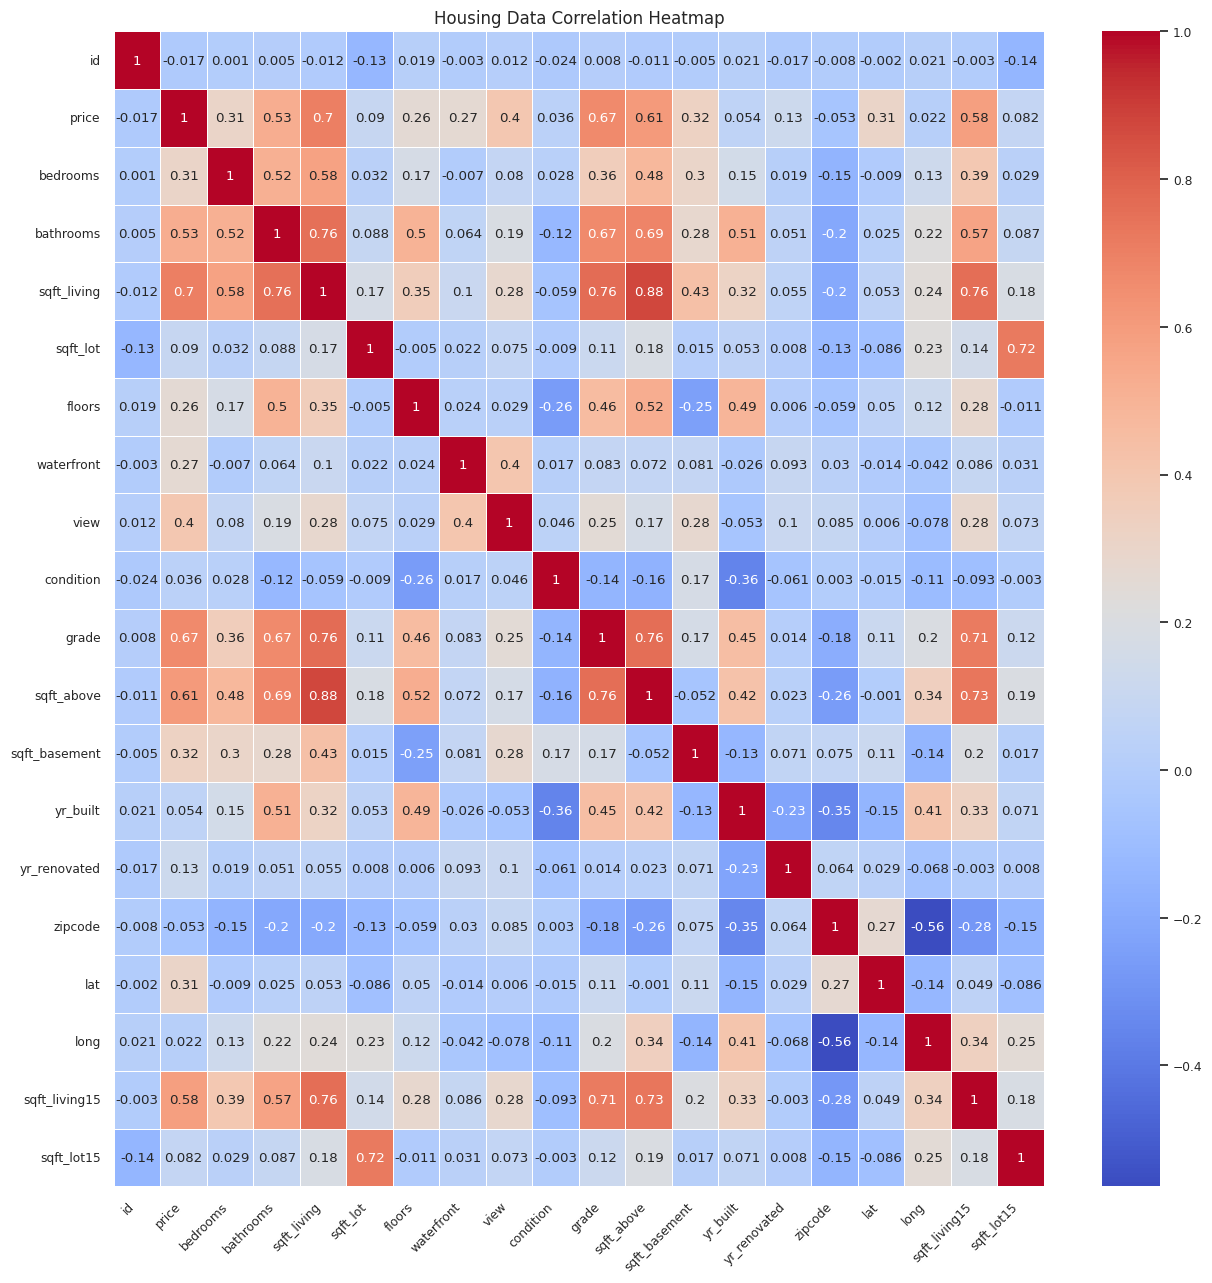

In [17]:
# Using heatmap, we will chart the correlations of all the features

plt. figure(figsize=(15,15))
sns.set(font_scale=0.8) # Too crowded so I decreased the font size
ax=sns.heatmap(house_corr, cmap='coolwarm', annot=True, linewidths = 0.5, cbar =True)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Housing Data Correlation Heatmap', fontsize = 12)

plt.show()



## Since the objective of this study is mainly to predict housing price based on property features, I will focus more based on the correlations between price and key features.



## **Let's do some individual charting based on the most related key features.**

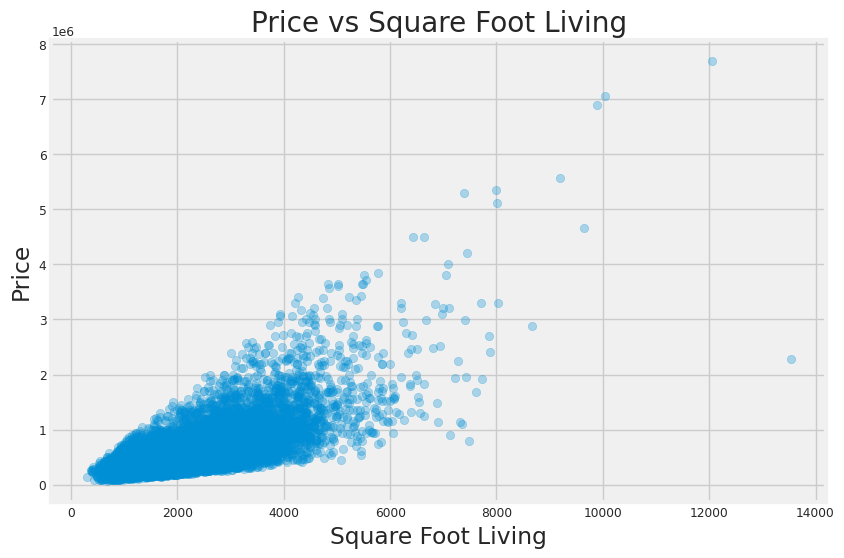

In [18]:
# from matplotlib import colormaps
# Price vs Square Foot Living

plt.figure(figsize =(10, 6))
plt.style.use('fivethirtyeight')
plt.scatter(housing['sqft_living'], housing['price'], alpha=0.3)
plt.xlabel('Square Foot Living')
plt.ylabel('Price')
plt.title('Price vs Square Foot Living')
plt.show()

Discovery:

Apart from some outliers, there is a strong positive correlation between living/livable square foot vs price.
The square foot living (sqft_living)is mostly concentrated < 4500 sqt

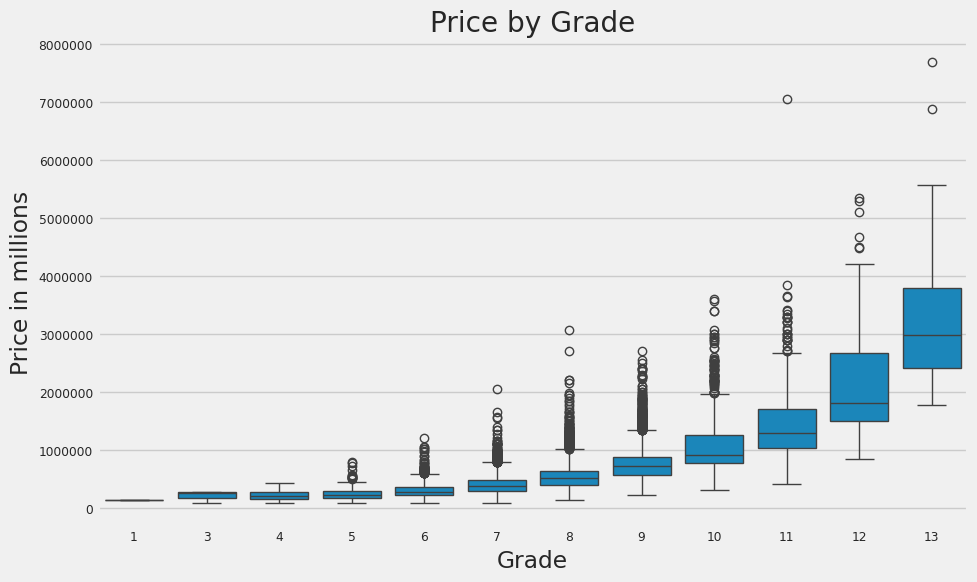

In [19]:
# Since grade is the 2nd storngest correlated feature, let's do a boxplot of
# price by grade.
# Even though grade is a int datatype, it is categorical in nature, (categorical -> price)

plt.figure(figsize =(10,6))
plt.style.use('fivethirtyeight')

sns.boxplot(x='grade', y='price', data= housing)

plt.title('Price by Grade')
plt.xlabel('Grade')
plt.ylabel('Price in millions')
plt.ticklabel_format(style='plain', axis='y')

plt.show()


Discovery:


* Price goes go up gently with each grade level until grade 8
* After grade 8, the price incremental more dramastically
* After grade 10, the price more than doubles that of grade 8 or even grade 9
* After grade 11, the price increases sustaintially, almost doubling that of grade 11

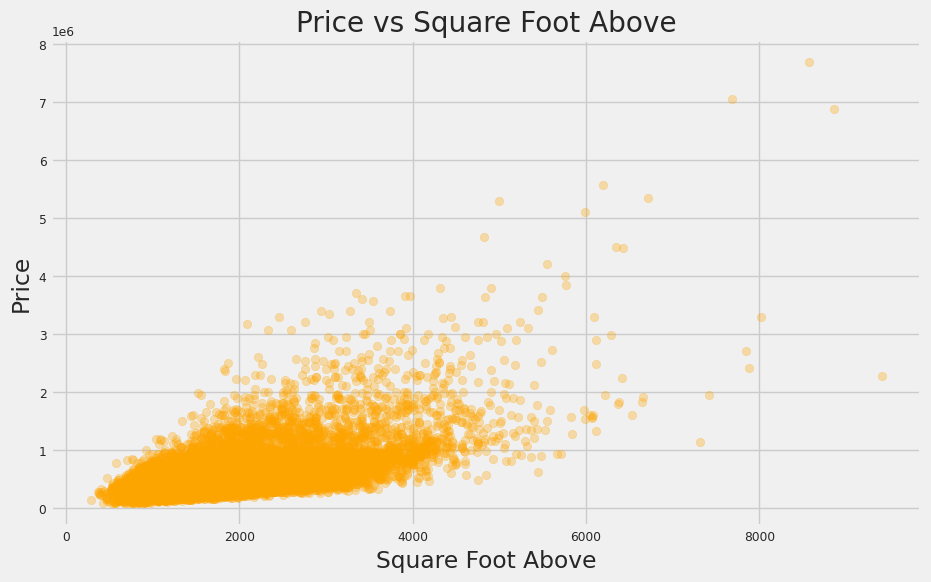

In [20]:
# from matplotlib import colormaps
# price vs square foot above

plt.figure(figsize =(10, 6))
plt.style.use('fivethirtyeight')
plt.scatter(housing['sqft_above'], housing['price'], alpha=0.3, color='Orange')
plt.xlabel('Square Foot Above')
plt.ylabel('Price')
plt.title('Price vs Square Foot Above')
plt.show()

- Again, there is a positive relationship between the square foot aove and price

Skewness: 4.024069144684712
Kurtosis: 34.58554043194243


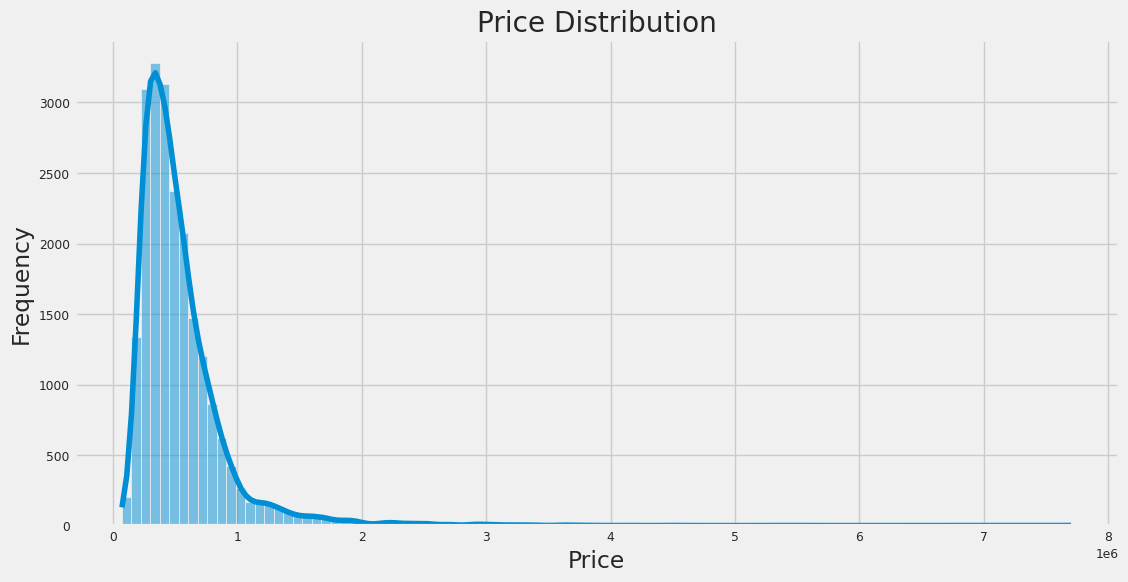

In [21]:
# Determine whether that the target variable is skewed and if so, how is it skewed.
# Let find out about the price sns.distributions by uing a histogram

plt.figure(figsize= (12,6))
sns.histplot(housing['price'], bins=100, kde=True, color='C0')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

# let's find the skewness and the tail in metrics
print(f'Skewness: {housing["price"].skew()}')
print(f'Kurtosis: {housing["price"].kurt()}')

## Discovery:

### The chart below shows a highly-skewed curve
### Skewness is =4.02, which is above the normal -1 to +1 range
- Most house prices are clustered at the lower end
- A righ long tail indicated a very small number of extreamely expensive homes
- The mean is inflated because of the outliers

### Kurtosis = 34.59, which is much higher than normal range of 3 (heavy tails)
- The tail is not long but very heavy
- The rare and yet extreamely expensive house prices increase the kurtosis

### Price is highly right-skewed with extreme but valid values. Very strong positve relationships between price and square footage, grade and square above.
Scatter plots indicate increasing variance at higher values, suggesting potential sensitivity to extreme feature values.

In [22]:
# Take a look at the IQR
housing_q1 = housing['price'].quantile(.25)
housing_q3 = housing['price'].quantile(.75)
print(f'25% House price are below: ${housing_q1}, 75% House price are below: ${housing_q3}')

iqr_price = housing_q3 - housing_q1
lower_bound_price = housing_q1 - (1.5 * iqr_price)
upper_bound_price = housing_q3 + (1.5 * iqr_price)

print(f'The house price range from 25% to 75% are: {iqr_price}')
print(f'The lower bound is: {lower_bound_price}')
print(f'The upper bound is: {upper_bound_price}')


25% House price are below: $321950.0, 75% House price are below: $645000.0
The house price range from 25% to 75% are: 323050.0
The lower bound is: -162625.0
The upper bound is: 1129575.0



## Discovery:
- The negative lower bound reflects strong right-skewed in prices.
- These extreme values are due to the expensive properties and were therefore retained. The model can benefit from a log transformation to smooth the unbalanced skewness.

### Baseline Model

* We will build a baseline linear regression model using a selected set of strong,
indicators based on correlation analysis and domain knowledge. No winsorization or transformation was involved. This baseline model will be a reference point for evaluating the impact of our following steps.

* The model will exclude 'sqft_living15' and 'sqft_lot15' because they do not describe the house but it's neighborhood after 2015 and further more they can potentially leak information.

In [23]:
# Baseline model1
# This model uses more features

import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

baseline_features = [  # 16 features
    'sqft_living',
    'grade',
    'sqft_above',
    'sqft_lot',
    'sqft_basement',
    'view',
    'waterfront',
    'bedrooms',
    'bathrooms',
    'floors',
    'yr_renovated',
    'yr_built',
    'lat',
    'long',
    'condition',
    'zipcode'
]

X = housing[baseline_features]
y = housing['price']

# split the train/test at 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.25, random_state=42)

#  We should scale some features such as, sqft_living (thousands), lat/long (small decimals),
# and grade (small integers), before fitting our models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

{'R2 Train': 0.6967185007092436,
 'R2 Test': 0.7036361064377242,
 'MAE Train': 125178.02201745358,
 'MAE Test': 126842.36660965045,
 'RMSE Train': np.float64(198416.66065898686),
 'RMSE Test': np.float64(210552.53684500334)}

In [24]:
# This model uses reduced features

import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

baseline_features = [   # 13 features
    'sqft_living',
    'grade',
    'sqft_above',
    'sqft_lot',
    'sqft_basement',
    'view',
    'waterfront',
    'bedrooms',
    'bathrooms',
    'floors',
    'lat',
    'long',
    'condition'
]

X = housing[baseline_features]
y = housing['price']

# split the train/test at 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.25, random_state=42)

#  We should scale some features such as, sqft_living (thousands), lat/long (small decimals),
# and grade (small integers), before fitting our models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

{'R2 Train': 0.6702268260006988,
 'R2 Test': 0.6820492575596702,
 'MAE Train': 131153.14757029546,
 'MAE Test': 132934.94766737567,
 'RMSE Train': np.float64(206901.11883190504),
 'RMSE Test': np.float64(218085.98352958105)}

* The results between training and test are consistent, indicating stable genearalization.
* The R2 scores are approximately .68, which decreased slightly using reduced features.
* The MAE indicates there is some underfitting
* THe RMSE indicates there some significant amount of underfitting

---
## Due to the strong right-skewness in housing prices, we can try appling a log transformation to the target variable


In [25]:
# Features/target
X = housing[baseline_features]
y = housing['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.25, random_state=42)

# Scale only features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Log-transform only target (and safely)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


# Fit and train
log_baseline_lr = LinearRegression()
log_baseline_lr.fit(X_train_scaled, y_train_log)

def evaluate_log_model(model, X_train, X_test, y_train, y_test):
    y_pred_train = np.expm1(model.predict(X_train))
    y_pred_test  = np.expm1(model.predict(X_test))

    return {
        'R2 Train': r2_score(y_train, y_pred_train),
        'R2 Test': r2_score(y_test, y_pred_test),

        'MAE Train': mean_absolute_error(y_train, y_pred_train),
        'MAE Test': mean_absolute_error(y_test, y_pred_test),

        'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    }

log_results = evaluate_log_model(log_baseline_lr, X_train_scaled, X_test_scaled, y_train, y_test)
log_results


{'R2 Train': 0.6852066202209744,
 'R2 Test': 0.35661961506811124,
 'MAE Train': 116433.34271493676,
 'MAE Test': 123502.3710027709,
 'RMSE Train': np.float64(202147.3126642032),
 'RMSE Test': np.float64(310228.53401212295)}

## Discovery:

We tried to apply a log transformation to the target variable to correct right skewness in housing prices.
* The R2 test performance deterioated significantly.
* There was a large increase in RMSE and a huge ga between the training and testing RMSE score. This indicates reduced generalization, suggesting that the baseline linear model works better for this dataset. It also points to the fact that this dataframe is a hard problem for linear models.
* We will use the baseline model from now on.

## We can also improve the model by winsorize data in some features.
###  We want features that are:
   * continuous numberic variables
   * contain extreme but valid values (not known outliers)
   * will impact co-efficients

### We won't select features that are:
  * ordinal or categorical encoding ('grade', 'view')
  * binary ('waterfront')
  * geographical location ('lat', 'long')
  * do not have extreme values
  * have low impacts on co-efficients
  
### We will use 'sqft_living' and 'sqft_lot' for our winsorization features.



In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Thresholds to test
thresholds = [
    (0.01, 0.99),
    (0.03, 0.97),
    (0.05, 0.95),
    (0.07, 0.93),
    (0.075, 0.9225),
    (0.10, 0.90),
    (0.15, 0.85),
    (0.20, 0.80),
  ]

# These are the columns to winsorize.
winsor_cols = [
    'sqft_living',
    'sqft_lot',
  ]

def winsorize_series(s, lower_q, upper_q):
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower=lower, upper=upper)

results = []

# Make a copy of the columns we want to winsorize
for lower_q, upper_q in thresholds:
    # Make a copy of the columns we want to winsorize
    housing_temp = housing.copy()

    # apply winsorization
    for col in winsor_cols:
        housing_temp[col] = winsorize_series(housing_temp[col], lower_q, upper_q)

    X = housing_temp[baseline_features]
    y = housing_temp['price']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    # Scaling
    ss = StandardScaler()
    X_train_scaled = ss.fit_transform(X_train)
    X_test_scaled = ss.transform(X_test)

    # Linear Regression model
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)

    y_pred_test = lr.predict(X_test_scaled)
    y_pred_train = lr.predict(X_train_scaled)

    results.append({
        'lower_q': lower_q,
        'upper_q': upper_q,
        'r2_train': r2_score(y_train, y_pred_train),
        'r2_test': r2_score(y_test, y_pred_test),
        'mae_train': mean_absolute_error(y_train, y_pred_train),
        'mae_test': mean_absolute_error(y_test, y_pred_test),
        'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    })

results_housing = pd.DataFrame(results)
results_housing

,lower_q,upper_q,r2_train,r2_test,mae_train,mae_test,RMSE Train,RMSE Test
0,0.010,0.9900,0.699544,0.671263,126695.207074,129890.911022,197490.244296,221754.442967
1,0.030,0.9700,0.700548,0.692017,125549.615631,128599.995212,197159.972509,214640.315308
2,0.050,0.9500,0.701765,0.697984,125154.527135,128252.037872,196758.913050,212550.847766
3,0.070,0.9300,0.701650,0.699913,125223.531099,128443.444049,196796.847404,211871.038670
4,0.075,0.9225,0.701962,0.700356,125065.021780,128326.433119,196694.090248,211714.524912
5,0.100,0.9000,0.700760,0.700814,125453.820088,128645.526409,197090.191060,211552.514866
6,0.150,0.8500,0.698620,0.700548,126176.561410,129181.834393,197793.553342,211646.731287
7,0.200,0.8000,0.696868,0.699856,126513.505317,129478.041918,198367.673825,211890.931345


## Discovery:
- After winsorizing a set of threashold to the whole housing dataset, we now can compare model performance.
- The R2_train and R2_test are relatively similar. MAE_train and MAE_test show consistent underfitting. RMSE_train and RMSE_test demonstrate the most underfitting.
- The 10/90 percentile produces the best performace for R2_test (0.7007), RMSE_test (211k). MAE_test could use a better tuning (128k).
- The baseline model, however, has better results. The baseline model results are: R2_test (0.703), RMSE_test (211k) and MAE_test (127K). It also has a smaller difference between RMSE_train and RMSE_test.
- In otherwords, the extreme values in 'sqft_lving' and 'sqft_lot' are informative but winsorization removes the signal and not just noise.

## Winsorization was a good reasonable experiment but probably will not be beneficial in this dataset.



## Discovery:
- Using 10/90 percentile, we will modify 2 features on 648 rows on a dataset of 6480 rows.

In [29]:
# # Transform the outliers by winsorizing them at 97/3 percentile
# # We will do split, winsorize, scale, then model to prevent data leakage

# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd

# # Train-test split
# # Split
# X = housing[baseline_features]
# y = housing['price']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.25, random_state=42
# )

# # Copy train and test dataset
# X_train_winsor = X_train.copy()
# X_test_winsor = X_test.copy()

# # Winsorizing TRAIN data using selected quantiles
# winsor_cols = [ 'sqft_living', 'sqft_lot' ]

# for col in winsor_cols:
#     upper = X_train_winsor[col].quantile(0.90)
#     lower= X_train_winsor[col].quantile(0.10)

#     X_train_winsor[col] = X_train[col].clip(lower=lower, upper=upper)
#     X_test_winsor[col] = X_test[col].clip(lower=lower, upper=upper)

# # Scaling
# ss = StandardScaler()
# X_train_scaled = ss.fit_transform(X_train_winsor)
# X_test_scaled = ss.transform(X_test_winsor)

# # results = []

# # Linear Regression model
# lr = LinearRegression()
# lr.fit(X_train_scaled, y_train)

# # Predict and Evaluate
# y_pred_train = lr.predict(X_train_scaled)
# y_pred_test = lr.predict(X_test_scaled)

# results = pd.DataFrame([{
#   'lower_quantile': lower,
#   'upper_quantile': upper,
#   'r2_train': r2_score(y_train, y_pred_train),
#   'r2_test': r2_score(y_test, y_pred_test),
#   'mae_train': mean_absolute_error(y_train, y_pred_train),
#   'mae_test': mean_absolute_error(y_test, y_pred_test),
#   'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
#   'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
# }])

# results


,lower_quantile,upper_quantile,r2_train,r2_test,mae_train,mae_test,RMSE Train,RMSE Test
0,3270.2,21324.0,0.700777,0.700883,125445.020925,128630.704929,197084.523961,211528.113979


In [30]:
# Let's inpect them before moving on
# Here are the first 5 rows from 97% and 3% each after winsorization
# They look correct, epecially the price column

# row_id_winsorized = [
#     5631500400,16000397,2524049179, 7855801670, 2025069065,
#     7960900060, 7424700045, 4168000060,
#     8658300340, 41000454, 8802400416, 3340401535
# ]
# housing[housing['id'].isin(row_id_winsorized)]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
18,16000397,20141205T000000,189000.0,2,1.00,1200,9850,1.0,0,0,...,7,1200,0,1921,0,98002,47.3089,-122.210,1060,5095
21,2524049179,20140826T000000,2000000.0,3,2.75,3050,44867,1.0,0,4,...,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336
92,4168000060,20150226T000000,153000.0,3,1.00,1200,10500,1.0,0,0,...,7,1200,0,1962,0,98023,47.3220,-122.351,1350,10500
153,7855801670,20150401T000000,2250000.0,4,3.25,5180,19850,2.0,0,3,...,12,3540,1640,2006,0,98006,47.5620,-122.162,3160,9750
246,2025069065,20140929T000000,2400000.0,4,2.50,3650,8354,1.0,1,4,...,9,1830,1820,2000,0,98074,47.6338,-122.072,3120,18841
269,7960900060,20150504T000000,2900000.0,4,3.25,5050,20100,1.5,0,2,...,11,4750,300,1982,2008,98004,47.6312,-122.223,3890,20060
282,7424700045,20150513T000000,2050000.0,5,3.00,3830,8480,2.0,0,1,...,9,2630,1200,1905,1994,98122,47.6166,-122.287,3050,7556
465,8658300340,20140523T000000,80000.0,1,0.75,430,5050,1.0,0,0,...,4,430,0,1912,0,98014,47.6499,-121.909,1200,7500
704,41000454,20140815T000000,130000.0,2,1.00,880,9000,1.0,0,0,...,5,880,0,1928,0,98188,47.4672,-122.291,1410,10000



## Discovery:
### Comparing the original price ('price_copy') and winsorized price column ('price')-
- the price of row #2, #18 (lower < 3%) has increased and capped at 3%
- the price of row #21 (> 97% ) has decreased and capped at 97%

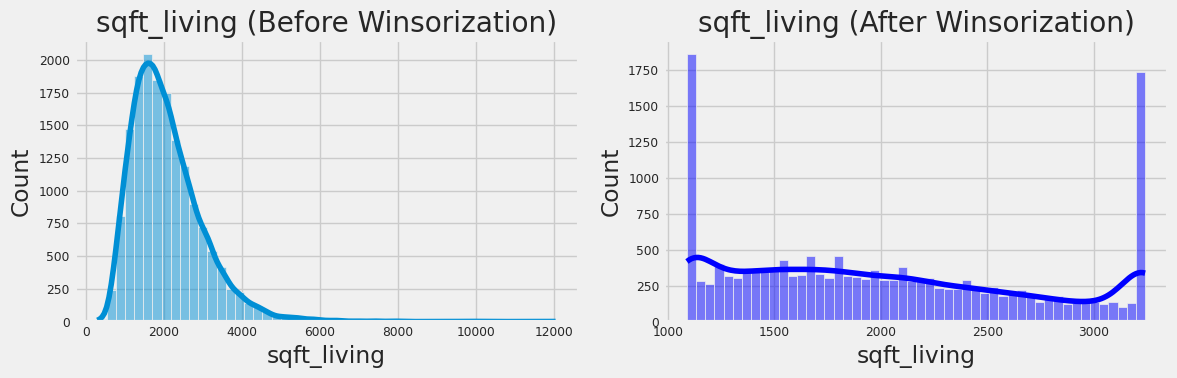

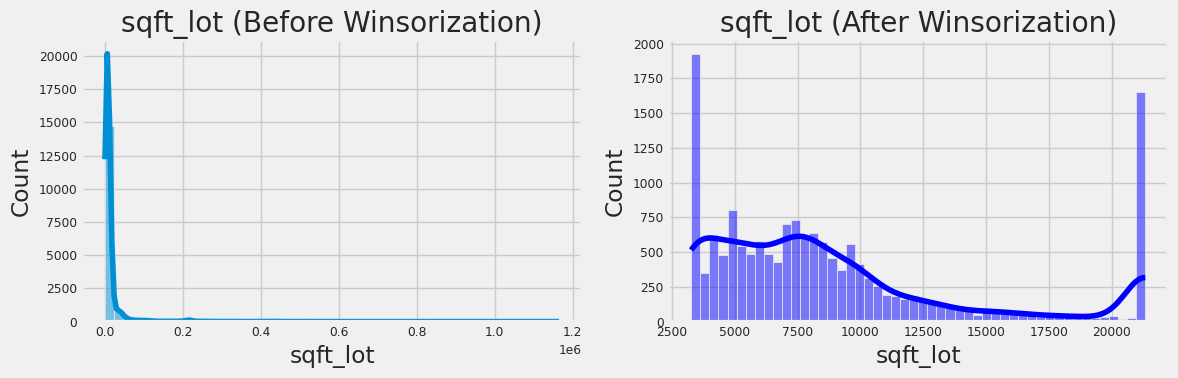

,feature,skew_before,skew_after,kurtosis_before,kurtosis_after
0,sqft_living,1.378634,0.385597,4.25563,-1.043976
1,sqft_lot,11.406146,1.183409,209.10870,0.422271


In [31]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import skew, kurtosis

# cols = ['sqft_living', 'sqft_lot']

# for col in cols:
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#     sns.histplot(X_train[col], bins=50, ax=axes[0], kde=True)
#     axes[0].set_title(f'{col} (Before Winsorization)')

#     sns.histplot(X_train_winsor[col], bins=50, ax=axes[1], kde=True, color='Blue')
#     axes[1].set_title(f'{col} (After Winsorization)')

#     plt.tight_layout()
#     plt.show()

# stats = []

# for col in cols:
#     stats.append({
#         'feature': col,
#         'skew_before': skew(X_train[col]),
#         'skew_after': skew(X_train_winsor[col]),
#         'kurtosis_before': kurtosis(X_train[col], fisher=True),
#         'kurtosis_after': kurtosis(X_train_winsor[col], fisher=True),
#     })

# skew_kurt_df = pd.DataFrame(stats)
# skew_kurt_df


## Discovery:
- The curve looks better on the chart & both the skewness and kurtosis improved
- Skewness: 1.377813134039648  - lightly beyond -1 to 1 range
- Kurtosis: 1.7229118540555515 - under 3 std

In [32]:
housing

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287



# Model Building
## Project Goal
- Build regression models to **predict housing prices** based on property features.
- Compare **Linear Regression, Ridge Regression, and Lasso Regression**.
- Evaluate models using metrics:
  - **R²** (variance explained)
  - **MAE** (mean absolute error)
  - **RMSE** (root mean squared error)

In [33]:
# Find the features that have the most correlations and use them for the modeling

house_price_corr= housing.corr(numeric_only=True)['price'].\
  sort_values(ascending=False).round(3)
house_price_corr


,price
price,1.000
sqft_living,0.702
grade,0.667
sqft_above,0.606
sqft_living15,0.585
bathrooms,0.525
view,0.397
sqft_basement,0.324
bedrooms,0.308
lat,0.307



## Discovery:
We will use the the baseline features for the predictive modeling because of their possible correlation with price


In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
# Taken from above we will use these features for our predicted modeling
baseline_features = [  # 16 features
    'sqft_living',
    'grade',
    'sqft_above',
    'sqft_lot',
    'sqft_basement',
    'view',
    'waterfront',
    'bedrooms',
    'bathrooms',
    'floors',
    'yr_renovated',
    'yr_built',
    'lat',
    'long',
    'condition',
    'zipcode'
]

X = housing[baseline_features]
y = housing['price']

# split the train/test at 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.25, random_state=42)

#  We should scale some features such as, sqft_living (thousands), lat/long (small decimals),
# and grade (small integers), before fitting our models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

{'R2 Train': 0.6967185007092436,
 'R2 Test': 0.7036361064377242,
 'MAE Train': 125178.02201745358,
 'MAE Test': 126842.36660965045,
 'RMSE Train': np.float64(198416.66065898686),
 'RMSE Test': np.float64(210552.53684500334)}

- R² Test = 0.703	The model explains 70.36% of price variance.
- R2 Traing and Test are very similar, just slightly underfitting
- MAE Test and Train are very similar,
- MAE Test is 127k
- RMSE Test and Train are not as similar
- RMSE is 211k

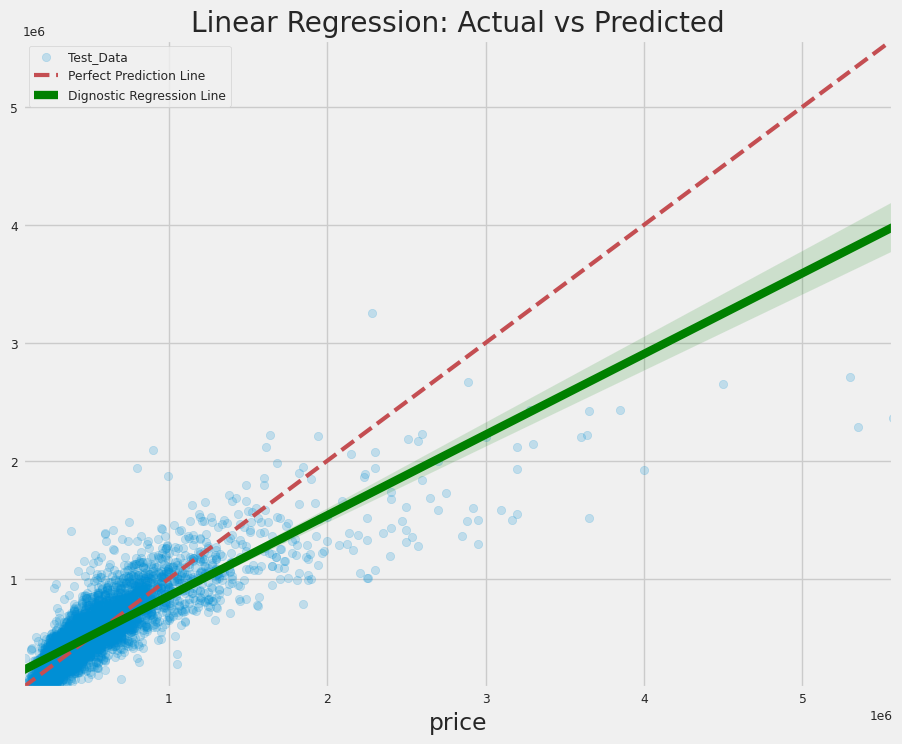

In [37]:
# Plot the Linear Regression

y_pred_housing_lr = baseline_lr.predict(X_test_scaled)

with plt.style.context('fivethirtyeight'):
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred_housing_lr, alpha = 0.2, label = 'Test_Data')

    # Need to have 2D points because we are not just testing 1 feature but
    # multiple features
    # with the min/max on y data forming 2 points so we can draw a line

  # set axis limits first and then plot the line to make the dots look clearner

    plt.xlim([y_test.min(), y_test.max()])
    plt.ylim([y_test.min(), y_test.max()])

    plt.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
    'r--', linewidth=3, label='Perfect Prediction Line')

  # Plot the diagnostic regression line
    sns.regplot(x=y_test, y=y_pred_housing_lr, scatter=False, color='green',
                label= 'Dignostic Regression Line')
    plt.title("Linear Regression: Actual vs Predicted")
    plt.legend()
    plt.show()



Text(0.5, 1.0, 'Residual vs Predicted Price for Linear Regression')

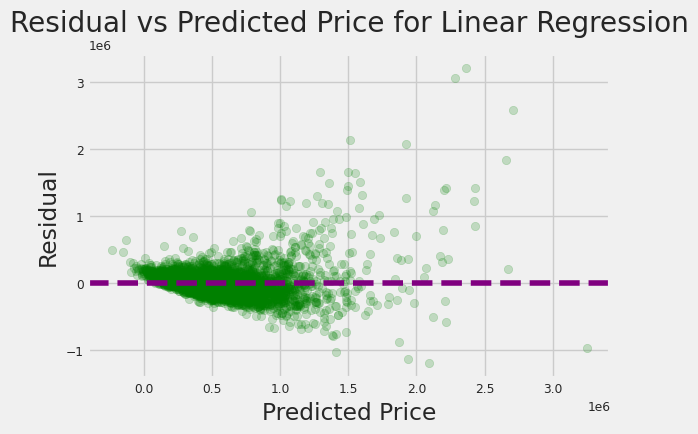

In [38]:
# I like to know where the predicted errors happen.
# Let's do a Residual vs Predicted Plot

residuals_lr = y_test - y_pred_housing_lr
# y_pred_housing_lr.min(), y_pred_housing_lr.max()
plt.figure(figsize=(6,4))
plt.scatter(y_pred_housing_lr, residuals_lr, alpha=0.2, color='green')
plt.axhline(y=0, color='purple', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual vs Predicted Price for Linear Regression')


## Discovery:
- The residuals are centered around zero, with most errors occuring 125K to 750k
- range. Error magnitude start to increase until it reaches at the height of
- 0.7 million or 700k price houses, where the model under predicts by 600,000,
- and at the lowest point, at 1.25 million, where the model over predicts by
- 600,000. But these few dots present themselves more like outliers rather than
- consistent prediction. Most of the residuals range roughly from −300,000 to
- +300,000

In [39]:
# The dataset has a large range value in price.
# Before I do Lasso and Ridge modeling,
# we need to scale the model because regularization (the penalty terms)
# depend on coefficient size.
# If model is not scaled, features with large numeric ranges get punished more,
# causing distorted coefficients or incorrect feature elimination.

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

# Initialize our model with the scaled data
ss = StandardScaler()

# Fit our scaled data on training data
X_trained_scaled = ss.fit_transform(X_train)

# Transform our scaled data on testing data
X_test_scaled = ss.transform(X_test)

# Convert back to DataFrame for readability

X_train_scaled = pd.DataFrame(X_trained_scaled, columns =X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)



In [40]:
# Lasso regression
from sklearn.linear_model import Ridge, Lasso

# Initialize the model using alpha = 600
lasso = Lasso(alpha=600)
lasso.fit(X_train_scaled, y_train)

# Evaluate the model
lasso_result = evaluate_model(lasso, X_train_scaled, X_test_scaled, y_train, y_test)
lasso_result


{'R2 Train': 0.6966672255406132,
 'R2 Test': 0.7032676918763432,
 'MAE Train': 124871.57891134686,
 'MAE Test': 126575.19989477395,
 'RMSE Train': np.float64(198433.4328949734),
 'RMSE Test': np.float64(210683.36676365306)}

In [94]:
# Can also use the Pipeline ()

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# lasso_pipe = Pipeline([
#     ('ss', StandardScaler()),
#     ('lasso', Lasso(alpha=600))
# ])

# lasso_pipe.fit(X_train, y_train)

# lasso_result1=evaluate_model(lasso_pipe, X_train, X_test, y_train, y_test)
# lasso_result1


In [95]:
# # Plot the Lasso scaled Regression

# y_pred_housing_lasso = lasso.predict(X_test_scaled)

# with plt.style.context('fivethirtyeight'):
#     plt.figure(figsize=(7, 7))
#     plt.scatter(y_test, y_pred_housing_lasso, alpha = 0.2, label = 'Test_Data', color='Orange')

#     # Need to have 2D points because we are not just testing 1 feature but
#     # multiple features
#     # with the min/max on y data forming 2 points so we can draw a line

#   # set axis limits first and then plot the line to make the dots look clearner
#     plt.xlim([y_test.min(), y_test.max()])
#     plt.ylim([y_test.min(), y_test.max()])

#     plt.plot([y_test.min(), y_test.max()],
#             [y_test.min(), y_test.max()],
#     'r--', linewidth=3, label='Perfect Prediction Line')

#   # Plot the diagnostic regression line
#     sns.regplot(x=y_test, y=y_pred_housing_lasso, scatter=False, color='green',
#                 label= 'Dignostic Regression Line')
#     plt.title("Lasso Regression: Actual vs Predicted")
#     plt.legend()
#     plt.show()

## Discovery:
### Linear Regression -
- It uses all features
- Imposes penalty
- Higher variance theoretically

### Lasso Regression
- Penalizes coefficient size
- Slightly more stable
- Can do feature selection (if needed)

### Both Linear Regression and Lasso Regression
- Have nearly identical predictive results and diagnostic patterns, indicating that the original feature
- Set generalizes well and does not require strong regularization.

In [41]:
# Ridge regression

# Initialize the model using alpha = 600
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Evaluate the model
Ridge_result = evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test)
Ridge_result


{'R2 Train': 0.6967184991685962,
 'R2 Test': 0.703633997525648,
 'MAE Train': 125175.71870421834,
 'MAE Test': 126840.40413131032,
 'RMSE Train': np.float64(198416.66116295778),
 'RMSE Test': np.float64(210553.28598484013)}

In [ ]:
# Plot the Ridge scaled Regression

y_pred_housing_ridge = ridge.predict(X_test_scaled)

with plt.style.context('fivethirtyeight'):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_pred_housing_ridge, alpha = 0.2, label = 'Test_Data', color='Purple')

    # Need to have 2D points because we are not just testing 1 feature but
    # multiple features
    # with the min/max on y data forming 2 points so we can draw a line

  # set axis limits first and then plot the line to make the dots look clearner
    plt.xlim([y_test.min(), y_test.max()])
    plt.ylim([y_test.min(), y_test.max()])

    plt.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
    'r--', linewidth=3, label='Perfect Prediction Line')

  # Plot the diagnostic regression line
    sns.regplot(x=y_test, y=y_pred_housing_ridge, scatter=False, color='green',
                label= 'Dignostic Regression Line')
    plt.title("Lasso Regression: Actual vs Predicted")
    plt.legend()
    plt.show()

In [43]:
# Let's see how many features Lasso removed: 0
(lasso.coef_ == 0).sum()

np.int64(1)

## Discovery:
- Lasso regularization did have to set a coefficients to zero, indicating that all but 1 selected features contribute meaningfully to the model and that strong regularization was not necessary.

- The result of Lasso is very similar to that of LR

In [98]:
# comparing coeff
pd.DataFrame({
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}, index=X_train.columns)


,Ridge,Lasso
sqft_living,174386.417911,173773.226203
sqft_above,1193.602410,0.000000
bathrooms,-383.332210,-0.000000
bedrooms,-22278.235909,-21073.292005
grade,93650.189083,93216.597681
view,52237.207387,52041.583639
waterfront,49329.739613,48916.593726
floors,-16616.561621,-15384.727957
lat,92915.856304,92329.639430
sqft_living15,2298.544041,2437.827776



## Discovery:
- While Ridge and Lasso coefficients differ in magnitude from the linear  regression coefficients due to feature scaling, Ridge and Lasso coefficients  are nearly identical to each other.
- Despite these refinement, R2, MSE, RMSE rates remain similar. This suggests that regularization has limited impact on improving model performance or altering feature importance, indicating that model complexity is not the primary limitation.

---
## Price Segmentation Alternative


In [44]:
# Using the original to re-make the housing dataframe

housing = housing_raw.copy()
housing.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## To further investigate the underlying price dynamics, the original dataset is re-examined:
* The median home price (\$450K) and the mean price (\$540K) are relatively close, suggesting that most home prices are concentrated around the middle of the distribution. However, there is a substantial gap between the 75th percentile (\$645K) and the maximum price (\$7.7M), indicating the presence of extreme high-end outliers.
* This large disparity suggests that the price distribution is right-skewed and that a single global pricing model may not adequately capture the dynamics of ultra-expensive homes.


## As a result, it may be appropriate to develop a separate pricing model for the high-end segment of the market.

---

### Segmentation options:
Model set 1:
* Standard homes: bottom 75%
* High-end homes: top 25%

Model set 2:
* Standard homes: bottom 90%
* Ultra-high-end homes: top 10%


In [47]:
# Model set 1 using 25/75 house value sas threasholds to split the dataset into
# standard and high-end homes.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model set 1 lower subset (low_75)
cutoff_75 = housing['price'].quantile(0.75)
low_75 = housing[housing['price'] < cutoff_75]
# high_end_75 = housing[housing['price'] >= cutoff_75]

# We use the set that has the most features
baseline_features = [
    'sqft_living',
    'grade',
    'sqft_above',
    'sqft_lot',
    'sqft_basement',
    'view',
    'waterfront',
    'bedrooms',
    'bathrooms',
    'floors',
    'yr_renovated',
    'yr_built',
    'lat',
    'long',
    'condition',
    'zipcode'
]

X_low_75 = low_75[baseline_features]
y_low_75 = low_75['price']

# split the train/test at 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X_low_75, y_low_75, test_size =0.25, random_state=42)

#  We should scale some features such as, sqft_living (thousands), lat/long (small decimals),
# and grade (small integers), before fitting our models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

# # Linear Regression
# lr = LinearRegression()
# lr.fit(X_train, y_train)
# lr_result = evaluate_model(lr, X_train, X_test, y_train, y_test)
# lr_result


{'R2 Train': 0.5917691377313712,
 'R2 Test': 0.5954771433300379,
 'MAE Train': 63578.683682770876,
 'MAE Test': 63042.97604318917,
 'RMSE Train': np.float64(80722.77363770625),
 'RMSE Test': np.float64(80001.80792111125)}

In [48]:

# Model set 1 higher subset (high_end_75)

# cutoff_75 = housing['price'].quantile(0.75)
# low_75 = housing[housing['price'] < cutoff_75]
high_end_75 = housing[housing['price'] >= cutoff_75]

# baseline features are the same

X_high_end_75 = high_end_75[baseline_features]
y_high_end_75 = high_end_75['price']

# split the train/test at 75/25
X_train, X_test, y_train, y_test = train_test_split(
X_high_end_75, y_high_end_75, test_size =0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

# # Linear Regression
# lr = LinearRegression()
# lr.fit(X_train, y_train)
# lr_result = evaluate_model(lr, X_train, X_test, y_train, y_test)
# lr_result

{'R2 Train': 0.610646020099328,
 'R2 Test': 0.6099587354220957,
 'MAE Train': 200914.9560528346,
 'MAE Test': 194060.2550227605,
 'RMSE Train': np.float64(304530.7269305184),
 'RMSE Test': np.float64(272851.15841278865)}

* Also the R2 scores between low_75 and high_end_75 are very similar, the MAE score dropped sustaintially.
* However, this is compensated with a lower RMSE score.

## We will create another model with 2 segmentations, split by the 10/90 house value thresholds.



In [50]:
# Model set 2 using 10/90 house value sas threasholds to split the dataset into
# standard and high-end homes.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model set 2 lower subset (low_90)
cutoff_90 = housing['price'].quantile(0.90)
low_90 = housing[housing['price'] < cutoff_90]
# high_end_90 = housing[housing['price'] >= cutoff_90]

# We use the set that has the most features
baseline_features = [
    'sqft_living',
    'grade',
    'sqft_above',
    'sqft_lot',
    'sqft_basement',
    'view',
    'waterfront',
    'bedrooms',
    'bathrooms',
    'floors',
    'yr_renovated',
    'yr_built',
    'lat',
    'long',
    'condition',
    'zipcode'
]

X_low_90 = low_90[baseline_features]
y_low_90 = low_90['price']

# split the train/test at 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X_low_90, y_low_90, test_size =0.25, random_state=42)

#  We should scale some features such as, sqft_living (thousands), lat/long (small decimals),
# and grade (small integers), before fitting our models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

# # Linear Regression
# lr = LinearRegression()
# lr.fit(X_train, y_train)
# lr_result = evaluate_model(lr, X_train, X_test, y_train, y_test)
# lr_result

{'R2 Train': 0.6695665627798226,
 'R2 Test': 0.6442215378144618,
 'MAE Train': 79299.18244290304,
 'MAE Test': 80855.95225125353,
 'RMSE Train': np.float64(102461.50788630889),
 'RMSE Test': np.float64(104913.03745667684)}

In [51]:
# Model set 2 higher subset (high_end_90)

# cutoff_90 = housing['price'].quantile(0.90)
# low_90 = housing[housing['price'] < cutoff_90]
high_end_90 = housing[housing['price'] >= cutoff_90]

# baseline features are the same

X_high_end_90 = high_end_90[baseline_features]
y_high_end_90 = high_end_90['price']

# split the train/test at 10/90
X_train, X_test, y_train, y_test = train_test_split(
X_high_end_90, y_high_end_90, test_size =0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit baseline linear regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train)

# Define a function that returns R2, MSE, RMSE training and test dataset
def evaluate_model(model, X_train, X_test, y_train, y_test):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  return {
      'R2 Train': r2_score(y_train, y_pred_train),
      'R2 Test': r2_score(y_test, y_pred_test),

      'MAE Train': mean_absolute_error(y_train, y_pred_train),
      'MAE Test': mean_absolute_error(y_test, y_pred_test),

      'RMSE Train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
      'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
  }

baseline_result = evaluate_model(baseline_lr, X_train_scaled, X_test_scaled, y_train,
                                 y_test)
baseline_result

{'R2 Train': 0.5903211703783016,
 'R2 Test': 0.5510761486259226,
 'MAE Train': 268256.7319918327,
 'MAE Test': 271031.36276834167,
 'RMSE Train': np.float64(381041.4747341507),
 'RMSE Test': np.float64(377316.0351065022)}

# Final Analysis:

* Prior to segmentation, a global linear model achieved an R2 of approximately 66% with and without regularization, indicating moderate explanatory power across the full housing market.

* However, segmenting the dataset reveals distinct pricing regimes. Models trained on the lower and mid-priced segments (≤75% and ≤90%) maintain comparable or slightly improved R2 values, suggesting more stable and linear price dynamics.

## In contrast, model performance deteriorates substantially for the top 10% of homes, where R2 declines sharply. This indicates that luxury home pricing is governed by nonlinear and unobserved factors not captured by standard structural features, and that a single linear model is insufficient for this segment.